These features are extracted from voice recordings and are used to analyze and detect the effects of Parkinson’s disease. Parkinson's affects motor control, including the muscles responsible for voice production, leading to irregularities in pitch, tone, and amplitude. These measurements provide critical input for machine learning models or statistical analyses to predict whether a person has Parkinson’s disease.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('parkinsons.csv')
df.head(10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [4]:
df.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

name: Patient/sample identifier.

MDVP:Fo(Hz): Average voice pitch.

MDVP:Fhi(Hz): Highest pitch.

MDVP:Flo(Hz): Lowest pitch.

Jitter (%/Abs/RAP/PPQ/DDP): Measures of frequency variation (voice instability).

Shimmer (dB/APQ3/APQ5/DDA): Measures of amplitude variation (loudness irregularity).

NHR: Noise in voice (higher = more noise).

HNR: Harmonics in voice (lower = noisier).

status: Health status (1 = Parkinson’s, 0 = Healthy).

RPDE/DFA: Measures of signal complexity.

spread1/spread2: Voice pattern deviations.

D2: Signal complexity.

PPE: Randomness in pitch periods.

In [5]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [6]:
df.shape

(195, 24)

In [7]:
df.drop(columns = 'name',inplace = True)

In [8]:
df['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

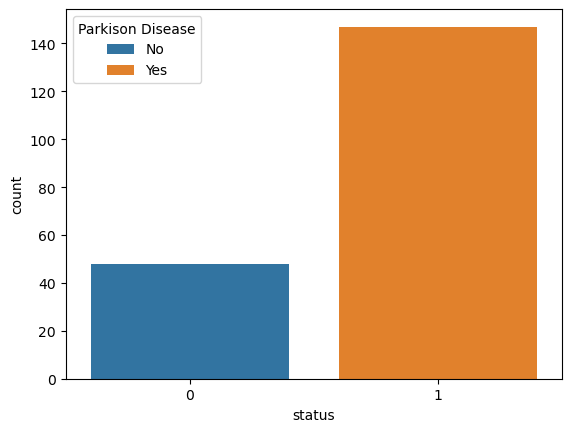

In [9]:
data = sns.countplot(data = df, x = df['status'], hue = 'status')
data.legend(title = 'Parkison Disease' ,labels = ['No','Yes'])
plt.show()

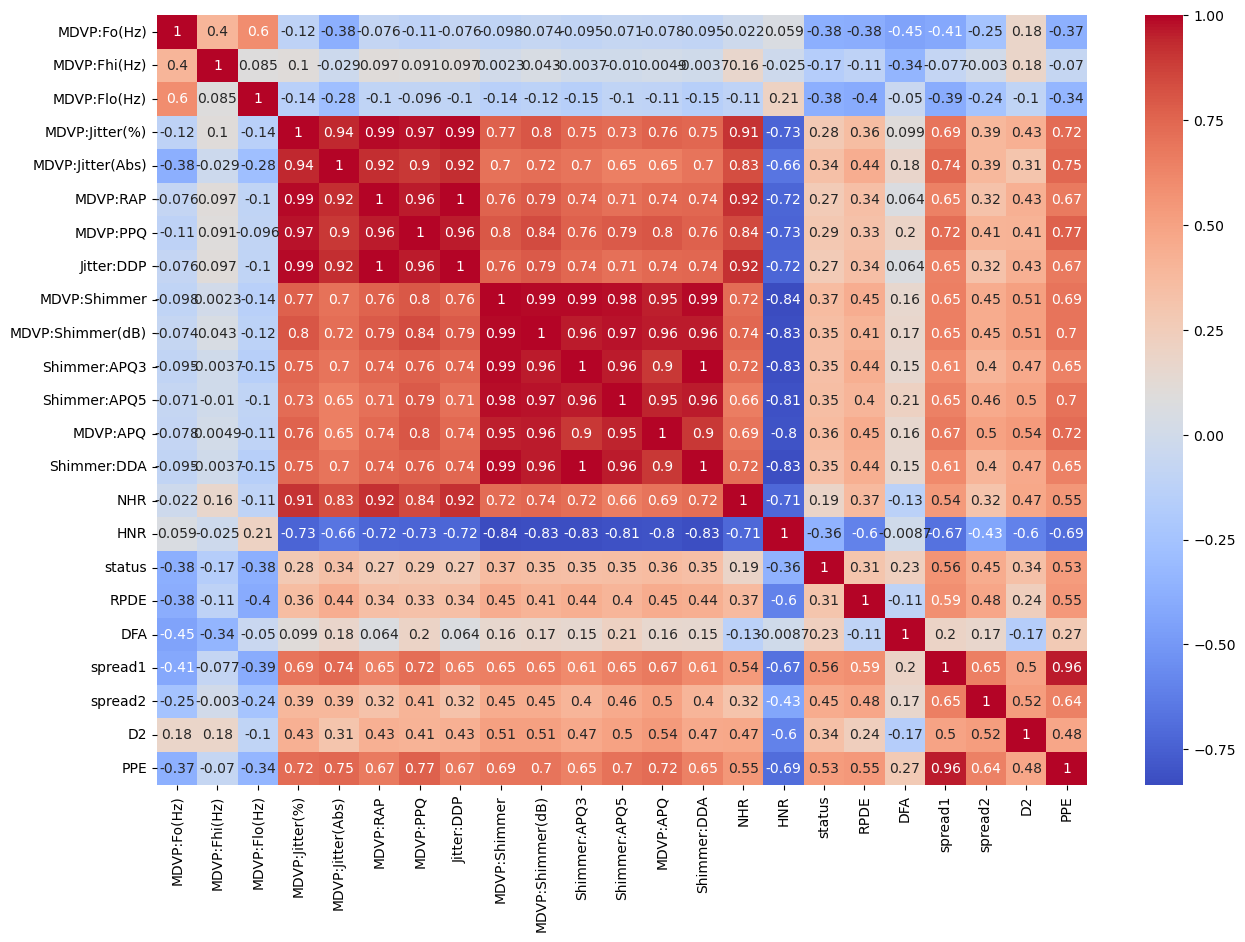

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(data = df.corr(),annot = True, cmap = 'coolwarm')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

In [1]:
x = df.drop(columns = 'status')
y = df['status']

NameError: name 'df' is not defined

In [13]:
# correlation_matrix = x.corr().abs()
# upper_triangle = correlation_matrix.where(
#     np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
# )
# to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
# x = x.drop(columns=to_drop)
# print(f"Dropped columns: {to_drop}")

In [14]:
df.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [17]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [18]:
models ={
    'Random Forest':RandomForestClassifier(n_estimators = 100),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel = 'linear', probability=True),
    'Naive Bayes': GaussianNB()
}
metrics = {
    "Model":[],
    "Accuracy" : [],
    "F1 Score": [],
    "Recall": [],
    "Precision":[]
}
for model_name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test,y_pred)
    F1 = f1_score(y_test,y_pred)
    Recall = recall_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(Recall)
    metrics['F1 Score'].append(F1)

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Accuracy  F1 Score   Recall  Precision
0        Random Forest  0.948718  0.969697  1.00000   0.941176
1  Logistic Regression  0.897436  0.941176  1.00000   0.888889
2        Decision Tree  0.923077  0.953846  0.96875   0.939394
3                  SVM  0.871795  0.923077  0.93750   0.909091
4          Naive Bayes  0.717949  0.813559  0.75000   0.888889


In [19]:
import optuna

In [20]:
from sklearn.model_selection import cross_val_score

In [21]:
def objective(trial):
    c = trial.suggest_float('C',0.1,100,log=True)
    kernel = trial.suggest_categorical('kernel',['linear','rbf','poly','sigmoid'])
    gamma = trial.suggest_categorical('gamma',['scale','auto'])

    model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)
    score = cross_val_score(model, x_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [22]:
study = optuna.create_study(direction = 'maximize')
study.optimize(objective,n_trials=60)

[I 2025-03-29 18:21:22,936] A new study created in memory with name: no-name-b6719a92-cc28-44a4-8bee-af87a4cad5a9
[I 2025-03-29 18:21:22,952] Trial 0 finished with value: 0.8461538461538461 and parameters: {'C': 0.5683085760813549, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 0 with value: 0.8461538461538461.
[I 2025-03-29 18:21:22,967] Trial 1 finished with value: 0.8653846153846153 and parameters: {'C': 11.946694227078606, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 1 with value: 0.8653846153846153.
[I 2025-03-29 18:21:22,981] Trial 2 finished with value: 0.8525641025641025 and parameters: {'C': 0.9336542076148784, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 1 with value: 0.8653846153846153.
[I 2025-03-29 18:21:22,997] Trial 3 finished with value: 0.8589743589743589 and parameters: {'C': 0.42283034489409604, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.8653846153846153.
[I 2025-03-29 18:21:23,012] Trial 4 finished with value: 0.8653846153846153 

In [23]:
print(f'Best Hyperparamters: {study.best_trial.params}')
print(f'Best Trial Accuracy: {study.best_trial.value}')

Best Hyperparamters: {'C': 50.33214739582411, 'kernel': 'rbf', 'gamma': 'auto'}
Best Trial Accuracy: 0.9294871794871794


In [24]:
best_model = SVC(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(x_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.95


In [25]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[0]
The Person does not have Parkinsons Disease


In [26]:
import pickle

In [27]:
filename = 'parkinson_model.sav'
pickle.dump(best_model,open(filename, 'wb'))

In [28]:
loaded_model = pickle.load(open('parkinson_model.sav','rb'))

In [29]:
for column in x.columns:
  print(column)

MDVP:Fo(Hz)
MDVP:Fhi(Hz)
MDVP:Flo(Hz)
MDVP:Jitter(%)
MDVP:Jitter(Abs)
MDVP:RAP
MDVP:PPQ
Jitter:DDP
MDVP:Shimmer
MDVP:Shimmer(dB)
Shimmer:APQ3
Shimmer:APQ5
MDVP:APQ
Shimmer:DDA
NHR
HNR
RPDE
DFA
spread1
spread2
D2
PPE
